# Section 4 &middot; Labeling Trades Right (the triple-barrier method)

*The Honest Edge.*

Section 3 ended on a cliffhanger. The Connors RSI-2 rule is a decent *candidate
generator*: it raises its hand on **168 distinct oversold dips** in 20 years. But it
takes every one blindly, the good and the bad, which is why it only ties buy-and-hold.
The plan from here is **meta-labeling**: train a model to look at each dip and decide
*take it, or skip it*.

Before a model can learn that, it needs an **answer key**: for each of those 168 dips,
was it actually a win or a loss? That sounds trivial, and it is the single easiest
place in this whole course to fool yourself. This section builds the answer key the
honest way, and counts how many *independent* lessons it really contains.

## Why "did it go up tomorrow?" is a bad label

The lazy label is *did the next bar close higher?* It quietly lies in three ways:

- **It ignores the path.** A trade can jump +4% on day two (you would have happily
  taken the profit) and still close day three in the red. "Next-bar direction" throws
  away everything that happened in between, which is exactly what a trader reacts to.
- **It ignores risk.** A dip that sags -6% before clawing back to +0.1% is scored an
  identical "win" to one that calmly rose +0.1%. One of those would have shaken you
  out; the label cannot tell them apart.
- **It ignores volatility regime.** A fixed "+2% = win" target is a near-certainty
  during a 2008-style panic and nearly unreachable in a sleepy 2017. The same label
  means different things in different years.

We want a label that respects how a real trade ends: it hits a **profit target**, gets
stopped at a **loss**, or you give up and close it after a while. That is the
**triple-barrier method** (Lopez de Prado, *Advances in Financial Machine Learning*,
2018, Ch. 3).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from honest_edge import data, indicators as ind, signal, labeling as lab

spy = data.load_spy_daily()
close = spy["close"]

# The DISTINCT dips, not the raw per-bar mask: the first bar of each oversold run.
# (Section 3 was careful about this: 280 condition-bars collapse to 168 real dips.
# Labeling the raw mask would double-count the same trade and corrupt the weights.)
entry, _ = signal.connors_rsi2_signals(spy, rsi_buy=10)
events = spy.index[entry & ~entry.shift(1, fill_value=False)]
print(f"distinct dips to label: {len(events)}")

distinct dips to label: 168


## Three barriers around every trade

Picture the bracket order a trader actually places at a brokerage: *take profit here,
stop me out there, and do not let me hold this thing forever.* Those are the three
barriers. We draw them around the entry and ask one question: **which does price touch
first?**

| barrier | where | meaning | label if hit first |
|---|---|---|---|
| **upper** (profit-take) | entry **+** k &times; ATR | the bounce paid off | **win** |
| **lower** (stop-loss) | entry **&minus;** k &times; ATR | the dip kept falling | **loss** |
| **vertical** (time limit) | `max_hold` bars later | it just drifted, time is up | **sign of the move** |

**Analogy: a bracket order with an egg timer.** Two horizontal lines (cash in, or cut
the loss) and a timer that goes off if neither line is touched. Whichever fires first
decides the trade. The vertical barrier matters more than it looks: without it, a trade
that goes nowhere would stay "open" forever and the label would secretly measure
long-run market drift instead of the trade.

## Why scale the barriers to volatility (ATR), not a fixed percent

The width of the two horizontal barriers is the whole game. Set them in **fixed
percent** and you mislabel by regime, as above. So we set them in units of
**ATR (Average True Range)**, the volatility gauge we defined back in Section 0 and
reserved for exactly this moment. ATR is the typical daily range *in price units*, so
"2 ATR away" is a barrier that is equally hard to reach in a calm month and a wild one.
A win then means the same thing in every regime.

Two honest notes before we pick numbers:

- **ATR vs the textbook's volatility.** De Prado scales barriers to a volatility
  estimate built from *returns*; we use ATR, a volatility estimate built from the
  *price range*. They are close cousins: on SPY, ATR-as-a-fraction-of-price runs at
  about **0.9&times;** the daily return standard deviation, so the two are
  interchangeable for this purpose. ATR wins here for teaching because it is a literal,
  drawable line on the chart.
- **We pick the multiplier _before_ looking at results.** It is tempting to dial the
  barrier width until the strategy looks great, but that is just peeking at the test
  set through the back door. So we fix a **symmetric** width of **k = 2 ATR** (same up
  and down) and a **5-day** time limit (the rule's natural hold is ~3 days; it exits on
  a 5-day average), chosen from convention, not from the answer. We will *look* at how
  the choice moves things later, but we do not *tune* it to win.

In [2]:
# Build a triple-barrier label for every dip. No look-ahead: the barriers are sized
# from ATR as of the ENTRY close, and the first-touch search walks strictly forward.
labels = lab.triple_barrier_labels(spy, events, side=1, atr_mult=2.0, max_hold=5)

print(f"dips labeled: {len(labels)}  (none dropped: every dip has 5 clear bars ahead)")
labels.head()

dips labeled: 168  (none dropped: every dip has 5 clear bars ahead)


,t1,entry,upper,lower,ret,outcome,hold,label
t0,,,,,,,,
2007-02-23,2007-02-27,145.30000,147.475223,143.124777,-0.039917,sl,2,0
2007-03-05,2007-03-12,137.35001,140.782662,133.917358,0.026502,pt,5,1
2007-03-28,2007-04-04,141.82001,144.988776,138.651244,0.014314,time,5,1
2007-05-24,2007-06-01,151.06000,153.674550,148.445450,0.019992,pt,5,1
2007-06-06,2007-06-07,151.84000,154.410399,149.269601,-0.018045,sl,1,0


## From three outcomes to one yes/no: the meta-label

The raw triple barrier gives three outcomes (+1 take-profit, &minus;1 stop, or the
timed-out sign). But our primary signal has *already decided the side of the bet*: we
are **always going long** the dip. When the side is fixed, the only thing left to learn
is **should we take this bet at all?**, and the label collapses to a clean **0 or 1**:

> **label = 1** if the trade ended in the green (profit-take, or a timeout that drifted
> up), **label = 0** if it ended in the red (stopped out, or a timeout that drifted down).

This is the **meta-label**. A profit-take is always a 1, a stop is always a 0, and only
the time-limit case is decided by the sign of the move. **1 = "this dip would have paid,
take it"; 0 = "skip it."** That binary is precisely what the Section 6 model will be
trained to predict, *before* the trade, from features describing the setup.

In [3]:
n = len(labels)
counts = labels["outcome"].value_counts()
print("how each trade ended:")
for oc, name in [("pt", "profit-take (win)"), ("sl", "stop-loss (loss)"), ("time", "time limit")]:
    print(f"  {name:22s} {counts.get(oc, 0):3d}   ({counts.get(oc, 0)/n:.0%})")

print(f"\nbase win rate (label = 1): {labels['label'].mean():.1%}")
print(f"median bars held:          {int(labels['hold'].median())}   (capped at the 5-day limit)")
print(f"decided by a real barrier: {(labels['outcome'] != 'time').mean():.0%}   (the rest timed out)")

how each trade ended:
  profit-take (win)       45   (27%)
  stop-loss (loss)        24   (14%)
  time limit              99   (59%)

base win rate (label = 1): 64.3%
median bars held:          5   (capped at the 5-day limit)
decided by a real barrier: 41%   (the rest timed out)


## Read it honestly

About **40% of dips are decided by a real price barrier** (profit-take or stop), and the
rest **time out**, because RSI-2 trades resolve fast: most never travel a full 2 ATR
within five days. That is not a flaw, it matches the rule's own short hold.

The number that matters is the **base win rate, about 64%**. Keep it in view, because it
is the bar Section 6 has to clear. The meta-model does **not** get credit for being
right 64% of the time, that is free, you get it by taking *every* dip. Its job is to be
**more selective**: skip enough of the eventual losers that the win rate among the
trades it *does* take climbs meaningfully above 64%, without throwing away too many
winners. If it cannot, meta-labeling adds nothing here, and we will say so.

## What a labeled trade looks like

Here is one example of each outcome: the entry, its two ATR barriers (dashed), the
5-day time limit (dotted), and the price path that decided it. The first barrier the
black line touches is the label.

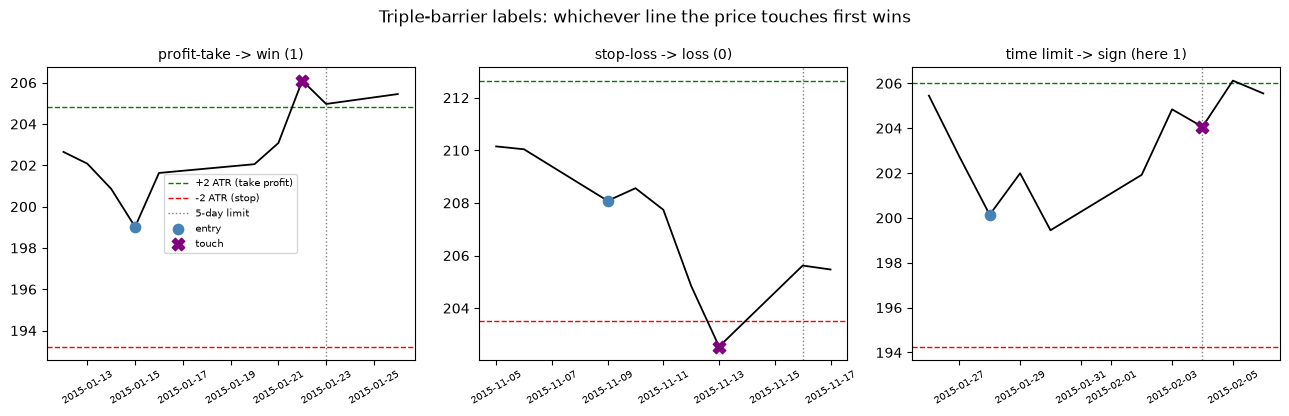

In [4]:
def first_example(outcome, after="2015-01-01"):
    sub = labels[(labels["outcome"] == outcome) & (labels.index > after)]
    return sub.iloc[0]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
titles = {"pt": "profit-take -> win (1)", "sl": "stop-loss -> loss (0)", "time": "time limit -> sign (here 1)"}
for ax, oc in zip(axes, ["pt", "sl", "time"]):
    row = first_example(oc)
    t0, t1 = row.name, row["t1"]
    win = slice(t0 - pd.Timedelta(days=4), t1 + pd.Timedelta(days=4))
    path = close.loc[win]
    ax.plot(path.index, path.values, color="black", lw=1.3, zorder=3)
    ax.axhline(row["upper"], color="green", ls="--", lw=1, label="+2 ATR (take profit)")
    ax.axhline(row["lower"], color="red", ls="--", lw=1, label="-2 ATR (stop)")
    vbar = close.index[close.index.get_indexer([t0])[0] + 5]
    ax.axvline(vbar, color="grey", ls=":", lw=1, label="5-day limit")
    ax.scatter([t0], [row["entry"]], color="steelblue", s=55, zorder=4, label="entry")
    ax.scatter([t1], [close.loc[t1]], color="purple", marker="X", s=80, zorder=5, label="touch")
    ax.set_title(titles[oc], fontsize=10)
    ax.tick_params(axis="x", labelrotation=30, labelsize=7)
axes[0].legend(fontsize=7, loc="best")
fig.suptitle("Triple-barrier labels: whichever line the price touches first wins")
plt.tight_layout()
plt.show()

## How sensitive is the label to our choices?

We fixed k = 2 ATR and a 5-day limit *a priori*. A fair question: how much do the labels
move if we had chosen differently? We **look**, but note clearly that we are not picking
the winner, just measuring the dial's sensitivity. Wider barriers or a longer leash let
the horizontal barriers actually trigger; tighter or shorter ones send more trades to
the time limit.

In [5]:
rows = {}
for k in [1.5, 2.0, 2.5]:
    for hold in [5, 10]:
        L = lab.triple_barrier_labels(spy, events, atr_mult=k, max_hold=hold)
        oc = L["outcome"].value_counts()
        rows[f"{k} ATR, {hold}d"] = {
            "win rate": L["label"].mean(),
            "profit-take": oc.get("pt", 0) / len(L),
            "stop-loss": oc.get("sl", 0) / len(L),
            "time-out": oc.get("time", 0) / len(L),
        }
pd.DataFrame(rows).T.style.format("{:.0%}")

,win rate,profit-take,stop-loss,time-out
"1.5 ATR, 5d",63%,42%,22%,36%
"1.5 ATR, 10d",60%,56%,35%,10%
"2.0 ATR, 5d",64%,27%,14%,59%
"2.0 ATR, 10d",60%,45%,31%,25%
"2.5 ATR, 5d",65%,15%,8%,76%
"2.5 ATR, 10d",61%,34%,21%,45%


The win rate is reassuringly **stable, in the low-to-mid 60s** across every setting: the
answer key is not an artifact of one lucky choice. What *does* move is the mix of how
trades end (wider or longer barriers convert time-outs into real profit-takes and stops),
which is mechanical and expected. We keep our pre-committed **2 ATR, 5-day** labels.

## The catch: these labels overlap, so they are not independent

There is a subtle trap hiding in this answer key. Dips sometimes arrive in **clusters**
(a choppy week can trigger two or three within days of each other), and each label
"lives" from its entry until its barrier touch. When two of those lifespans overlap in
time, the two labels share some of the **same future bars**, so they are partly the
**same observation counted twice**.

**Analogy: overlapping weather forecasts.** If Monday's 5-day forecast and Wednesday's
5-day forecast both cover Friday, Friday's storm shows up in both. Treat them as two
independent data points and you will think you have twice as much evidence about storms
as you really do. Machine learning makes the identical mistake unless we warn it.

The first step is just to **see** the overlap. We count, for each bar, how many labels
are alive on it (the *concurrency*). Where that count is above 1, trades overlap.

bars touched by at least one trade: 857
max trades alive at once:           2
share of active bars with overlap:  5%


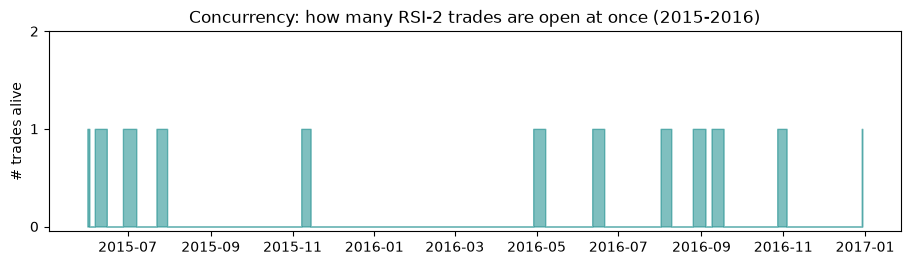

In [6]:
conc = lab.count_concurrent(spy.index, labels)
active = conc[conc > 0]
print(f"bars touched by at least one trade: {len(active)}")
print(f"max trades alive at once:           {int(conc.max())}")
print(f"share of active bars with overlap:  {(active > 1).mean():.0%}")

# A two-year slice where a couple of clusters are visible.
sl = slice("2015-06-01", "2016-12-31")
fig, ax = plt.subplots(figsize=(11, 2.6))
ax.fill_between(conc.loc[sl].index, conc.loc[sl].values, step="mid", alpha=0.5, color="teal")
ax.set_title("Concurrency: how many RSI-2 trades are open at once (2015-2016)")
ax.set_ylabel("# trades alive"); ax.set_yticks([0, 1, 2])
plt.show()

## Counting the trades we *actually* have: average uniqueness

The fix (Lopez de Prado, Ch. 4) is to weight each label by how **unique** its lifespan
is. On a bar where `c` trades are alive, each gets credit `1/c` for that bar; a label's
**average uniqueness** is the mean of those `1/c` values over its life. A trade that
never overlaps anything scores 1.0; one that shares every bar with a neighbor scores
about 0.5.

Summing those uniqueness scores gives the honest headline: the **effective number of
independent trades**, which is always less than or equal to the raw count.

In [7]:
uniq = lab.average_uniqueness(labels, conc)
print(f"raw labels:              {len(labels)}")
print(f"mean uniqueness:         {uniq.mean():.3f}")
print(f"EFFECTIVE labels (sum):  {uniq.sum():.0f}   <- the real sample size")
print()
print("On THIS strategy the haircut is small: dips sit ~3 weeks apart on average, so")
print("most trades barely overlap. But the mechanism is not optional. The same code on")
print("a signal that fired daily, or held for weeks, would shrink an apparent 1000")
print("trades to a couple of hundred. To make that concrete, three toy trades:")

# Three hand-built trades on a fake calendar: A and B overlap heavily, C is alone.
idx = pd.date_range("2020-01-01", periods=30, freq="D")
toy = pd.DataFrame(
    {"t1": [idx[5], idx[6], idx[25]]},
    index=pd.Index([idx[0], idx[1], idx[20]], name="t0"),
)
toy_conc = lab.count_concurrent(idx, toy)
toy_uniq = lab.average_uniqueness(toy, toy_conc)
for name, t0 in zip(["A (days 0-5)", "B (days 1-6)", "C (days 20-25, alone)"], toy.index):
    print(f"  {name:24s} uniqueness {toy_uniq[t0]:.2f}")
print(f"  -> 3 trades on paper, but only {toy_uniq.sum():.2f} independent ones.")

raw labels:              168
mean uniqueness:         0.955
EFFECTIVE labels (sum):  160   <- the real sample size

On THIS strategy the haircut is small: dips sit ~3 weeks apart on average, so
most trades barely overlap. But the mechanism is not optional. The same code on
a signal that fired daily, or held for weeks, would shrink an apparent 1000
trades to a couple of hundred. To make that concrete, three toy trades:
  A (days 0-5)             uniqueness 0.58
  B (days 1-6)             uniqueness 0.58
  C (days 20-25, alone)    uniqueness 1.00
  -> 3 trades on paper, but only 2.17 independent ones.


## One more refinement: weight by the size of the move

Uniqueness handles *redundancy*. De Prado's full sample weight adds *importance*: a
label driven by a big, decisive move carries more information than one that limped to a
flat time-out. The **return-attribution weight** combines both, it sums each bar's
return split across the trades alive on it (so no single day is double-counted), takes
the size of that sum, and normalizes the weights to average 1.

These weights are the third piece of the training set. In Section 6 we hand them to the
model as `sample_weight`, so it learns more from the clean, decisive, non-redundant
trades and less from the murky overlapping ones.

weights: mean 1.00 (by construction), range 0.01 to 4.30


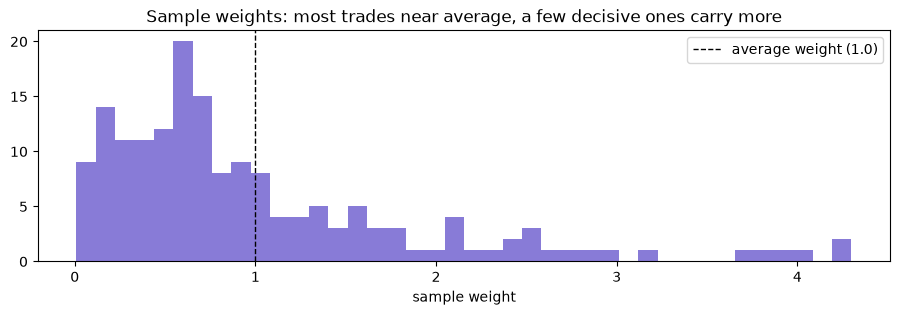

In [8]:
wts = lab.return_attribution_weights(close, labels, conc)
print(f"weights: mean {wts.mean():.2f} (by construction), range {wts.min():.2f} to {wts.max():.2f}")

fig, ax = plt.subplots(figsize=(11, 3))
ax.hist(wts, bins=40, color="slateblue", alpha=0.8)
ax.axvline(1.0, color="black", lw=1, ls="--", label="average weight (1.0)")
ax.set_title("Sample weights: most trades near average, a few decisive ones carry more")
ax.set_xlabel("sample weight"); ax.legend()
plt.show()

## The honest verdict, and what's next

We turned a vague question, *was this dip a win?*, into an honest, reproducible answer
key. Each of the 168 dips now carries:

- a **meta-label** (1 take / 0 skip) from a volatility-aware triple barrier, with a
  base win rate around **64%**, the number Section 6 must beat by being selective;
- an **average uniqueness**, exposing that the labels are not all independent (here a
  gentle haircut, but a discipline that scales);
- a **sample weight** that down-weights redundant, low-information trades.

What is still missing is the **X**: the features the model will read at each dip to make
its take-or-skip call, the trend regime, the depth of the pullback, momentum,
volatility, the overnight effect. That is **Section 5**. Then **Section 6** finally puts
it together: features in, meta-label out, weighted and validated honestly, to ask
whether filtering can turn "competitive" into a real edge.